In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('Algerian_forest_fires_cleaned.csv')

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
#drop day,month,year
df.drop(['day','month','year'],inplace=True,axis=1)

In [5]:
#Encoding
df['Classes']=np.where(df['Classes'].str.contains('not fire'),0,1)

In [6]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [7]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [8]:
#Independant And Dependant Features
X=df.drop('FWI',axis=1)
y=df['FWI']

In [9]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [10]:
#Feature Selection based on Correlation
df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

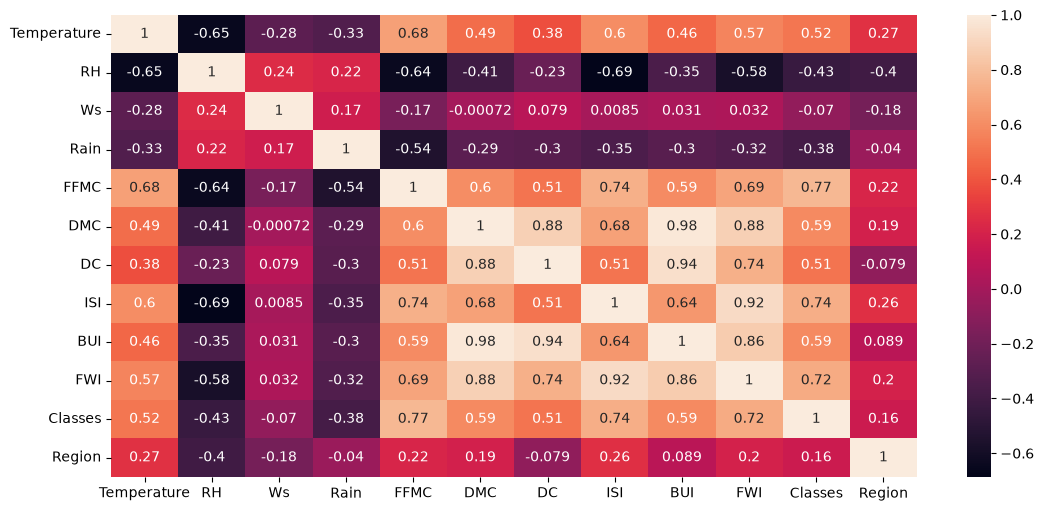

In [11]:
#check for multi colinearity
plt.figure(figsize=(13,6))
corr=df.corr()
sns.heatmap(corr,annot=True)

In [12]:
def correlation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]>threshold):
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr



In [13]:
corr_features=correlation(X_train,0.90)

In [14]:
#drop features when correlation is more than threshold
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)

In [ ]:
#Standardization
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'Classes', 'Region']


In [16]:
#LinearRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
linreg=LinearRegression()
linreg.fit(X_train,y_train)
y_pred=linreg.predict(X_test)
mae=mean_absolute_error(y_pred,y_test)
score=r2_score(y_test,y_pred)

print("Mean absolute error: ",mae)
print("R2 score: ",score)

Mean absolute error:  0.5170107980662408
R2 score:  0.9830565611009445


In [17]:
#Lasso regression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,r2_score
linreg=Lasso()
linreg.fit(X_train,y_train)
y_pred=linreg.predict(X_test)
mae=mean_absolute_error(y_pred,y_test)
score=r2_score(y_test,y_pred)

print("Mean absolute error: ",mae)
print("R2 score: ",score)

Mean absolute error:  1.1257992990774721
R2 score:  0.9498931628519823


In [18]:
#Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score
ridge=Ridge()
ridge.fit(X_train,y_train)
y_pred=ridge.predict(X_test)
mae=mean_absolute_error(y_pred,y_test)
score=r2_score(y_test,y_pred)

print("Mean absolute error: ",mae)
print("R2 score: ",score)

Mean absolute error:  0.5292519766274832
R2 score:  0.9824051915524249


In [19]:
#Elasticnet
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,r2_score
linreg=ElasticNet()
linreg.fit(X_train,y_train)
y_pred=linreg.predict(X_test)
mae=mean_absolute_error(y_pred,y_test)
score=r2_score(y_test,y_pred)

print("Mean absolute error: ",mae)
print("R2 score: ",score)

Mean absolute error:  1.7704255521425294
R2 score:  0.8887824924177792


In [20]:
#lasso CV
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train,y_train)

from sklearn.metrics import mean_absolute_error,r2_score
lassocv.fit(X_train,y_train)
y_pred=lassocv.predict(X_test)
mae=mean_absolute_error(y_pred,y_test)
score=r2_score(y_test,y_pred)

print("Mean absolute error: ",mae)
print("R2 score: ",score)

Mean absolute error:  0.5240497205739295
R2 score:  0.982187895589456


In [21]:
#RidgeCv
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error,r2_score
linreg=RidgeCV(cv=5)
linreg.fit(X_train,y_train)
y_pred=linreg.predict(X_test)
mae=mean_absolute_error(y_pred,y_test)
score=r2_score(y_test,y_pred)

print("Mean absolute error: ",mae)
print("R2 score: ",score)

Mean absolute error:  0.5292519766274832
R2 score:  0.9824051915524249


In [22]:
#ElasticNetCV
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error,r2_score
linreg=ElasticNetCV(cv=5)
linreg.fit(X_train,y_train)
y_pred=linreg.predict(X_test)
mae=mean_absolute_error(y_pred,y_test)
score=r2_score(y_test,y_pred)

print("Mean absolute error: ",mae)
print("R2 score: ",score)

Mean absolute error:  0.6133340328806134
R2 score:  0.9789643451363162


In [23]:
#pickle the machine learning model,preproccessing standardscaler
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))